# 02 — EDA: Flood-It! (`com.labpixies.flood`) — полный feature-вектор

## 0. Контекст

Это **per-app EDA для Flood-It!** — успешного продукта (`com.labpixies.flood`, 4,9M установок, 111 дней наблюдений). В отличие от source-ноутбуков, где мы смотрели одну группу источников по обоим приложениям, здесь мы фокусируемся **только на Flood-It!** и анализируем **полный 55-признаковый вектор** — то, что фактически видит модель ядерной регрессии для одной строки `(app_id, date)`.

**Структура:**
1. Контекст и загрузка
2. Качество данных по 4 источникам
3. Section A — **Product** (Firebase, 24 признака)
4. Section B — **Store** (Google Play, 17 признаков)
5. Section C — **Market** (краткий референс — общие с f2)
6. Section D — **External** (краткий референс — общие с f2)
7. **Cross-source synthesis** — главный вклад этого ноутбука: что коррелирует *между* источниками
8. Объединённый time-series 5 ключевых метрик
9. Выводы для Flood-It!

**Source-ноутбуки с детальным разбором каждой группы:**
- `01_source_product.ipynb`
- `01_source_store.ipynb`
- `01_source_market.ipynb`
- `01_source_external.ipynb`

**Гипотеза для успешного продукта:** Flood-It! должен показывать (а) сильную автокорреляцию product-метрик (стабильная аудитория), (б) высокий рейтинг с низкой волатильностью, (в) cross-source связи Product↔Store (поведение влияет на репутацию).

In [1]:
import sys
from pathlib import Path

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
sys.path.insert(0, str(_ROOT))

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.feature_engineering import load_dataset, compute_vif
from notebooks._common import (
    APP_PALETTE, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    split_by_app, top_correlated_pairs, check_inf_columns,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "02_eda_floodit"
APP_ID = "com.labpixies.flood"
df = load_dataset()
print(f"Dataset: {df.shape}")

Dataset: (222, 60)


In [2]:
PRODUCT_COLS = [
    "daily_installs", "daily_uninstalls", "net_installs",
    "dau", "mau", "wau", "stickiness",
    "retention_d1", "retention_d7", "retention_d30",
    "total_sessions", "median_session_duration", "avg_session_duration",
    "crash_rate", "onboarding_completion_rate", "peak_hour",
    "crash_rate_ma7", "avg_session_duration_ma7",
    "dau_growth_rate", "dau_growth_rate_7d", "install_growth_rate",
    "retention_d1_change", "retention_trend",
    "engagement_score",
]

STORE_COLS = [
    "rating", "reviews_count",
    "positive", "negative", "positive_ratio", "sentiment_score",
    "reviews_30d", "positive_30d", "negative_30d", "sentiment_30d",
    "rating_ma30", "positive_ratio_ma30",
    "rating_volatility_7d", "rating_trend", "negative_change",
    "downloads_index", "downloads_index_ma30",
]

MARKET_COLS = [
    "competitor_count", "category_rank",
    "competitor_count_change", "competition_volatility_7d",
    "category_rank_ma14", "category_rank_ma30",
    "rank_volatility_7d", "rank_improvement",
]

EXTERNAL_COLS = [
    "market_trend", "media_coverage",
    "market_sentiment", "media_coverage_ma7", "media_coverage_change",
    "seasonality_change",
]

SOURCE_GROUPS = {
    "Product": PRODUCT_COLS,
    "Store":   STORE_COLS,
    "Market":  MARKET_COLS,
    "External": EXTERNAL_COLS,
}
ALL_FEATURE_COLS = PRODUCT_COLS + STORE_COLS + MARKET_COLS + EXTERNAL_COLS
assert len(PRODUCT_COLS) == 24
assert len(STORE_COLS) == 17
assert len(MARKET_COLS) == 8
assert len(EXTERNAL_COLS) == 6
assert len(ALL_FEATURE_COLS) == 55
print(f"Group sizes: Product={len(PRODUCT_COLS)}, Store={len(STORE_COLS)}, "
      f"Market={len(MARKET_COLS)}, External={len(EXTERNAL_COLS)}")
print(f"Total feature cols: {len(ALL_FEATURE_COLS)}")

Group sizes: Product=24, Store=17, Market=8, External=6
Total feature cols: 55


## 1. Загрузка и общая структура

In [3]:
df_f1, df_f2 = split_by_app(df)
print(f"Flood-It! shape: {df_f1.shape}")
print(f"Период: {df_f1['date'].min().date()} — {df_f1['date'].max().date()} "
      f"({(df_f1['date'].max() - df_f1['date'].min()).days + 1} дней)")
display(df_f1[["date"] + ALL_FEATURE_COLS[:5]].head())

Flood-It! shape: (111, 60)
Период: 2018-06-12 — 2018-09-30 (111 дней)


,date,daily_installs,daily_uninstalls,net_installs,dau,mau
0,2018-06-12,13.0,13.0,0.0,134,134
1,2018-06-13,10.0,13.0,-3.0,144,227
2,2018-06-14,20.0,22.0,-2.0,142,301
3,2018-06-15,12.0,18.0,-6.0,145,375
4,2018-06-16,9.0,7.0,2.0,112,417


In [4]:
# dtypes summary по source-группам
rows = []
for group, cols in SOURCE_GROUPS.items():
    sub = df_f1[cols]
    rows.append({
        "group": group,
        "n_cols": len(cols),
        "n_float": (sub.dtypes == "float64").sum(),
        "n_int": (sub.dtypes.isin(["int64", "int32"])).sum(),
        "total_nan": sub.isna().sum().sum(),
        "nan_pct": round(sub.isna().sum().sum() / sub.size * 100, 2),
    })
display(pd.DataFrame(rows))

,group,n_cols,n_float,n_int,total_nan,nan_pct
0,Product,24,20,0,161,6.04
1,Store,17,17,0,45,2.38
2,Market,8,6,0,4,0.45
3,External,6,4,0,2,0.30


## 2. Качество данных по источникам

In [5]:
# NaN summary по группам
nan_per_col = df_f1[ALL_FEATURE_COLS].isna().sum()
nan_summary = []
for group, cols in SOURCE_GROUPS.items():
    sub = nan_per_col[cols]
    nan_summary.append({
        "group": group,
        "max_nan": int(sub.max()),
        "median_nan": int(sub.median()),
        "cols_with_nan": int((sub > 0).sum()),
        "total_cols": len(cols),
    })
display(pd.DataFrame(nan_summary))
print()
print("Топ-10 колонок по числу NaN у Flood-It!:")
display(nan_per_col.sort_values(ascending=False).head(10))

,group,max_nan,median_nan,cols_with_nan,total_cols
0,Product,79,0,9,24
1,Store,41,0,4,17
2,Market,1,0,4,8
3,External,1,0,2,6



Топ-10 колонок по числу NaN у Flood-It!:


retention_d30                 79
sentiment_30d                 41
retention_d7                  36
retention_d1_change           16
retention_d1                   9
retention_trend                8
dau_growth_rate_7d             7
onboarding_completion_rate     4
rating_trend                   2
install_growth_rate            1
dtype: int64

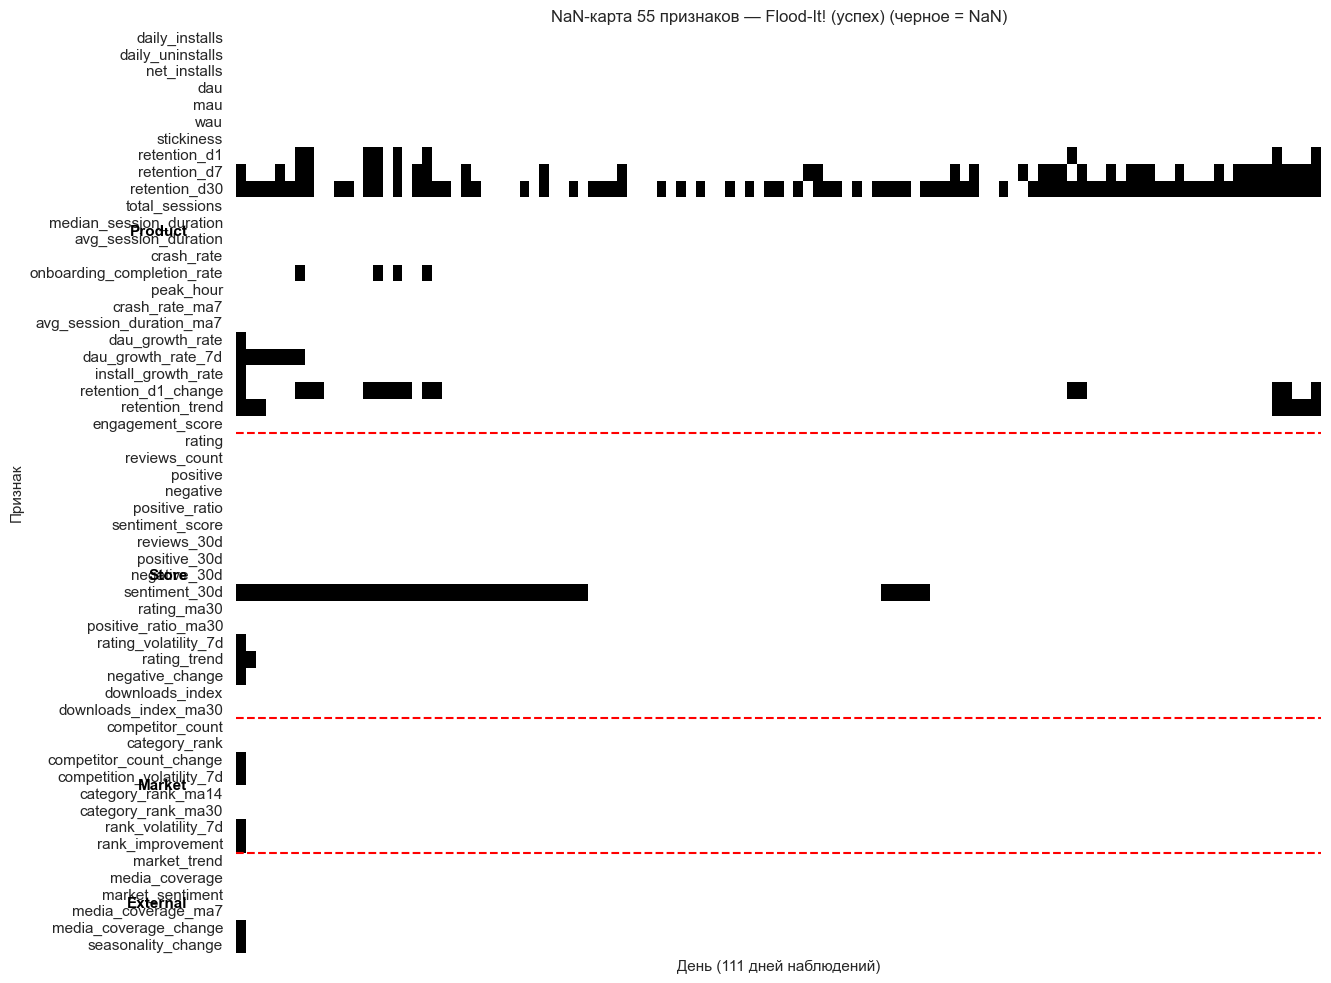

In [6]:
# NaN heatmap, grouped by source (вертикальные разделители групп)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    df_f1[ALL_FEATURE_COLS].isna().T.astype(int),
    cmap="binary", cbar=False, xticklabels=False, ax=ax,
)
group_boundaries = [
    len(PRODUCT_COLS),
    len(PRODUCT_COLS) + len(STORE_COLS),
    len(PRODUCT_COLS) + len(STORE_COLS) + len(MARKET_COLS),
]
group_labels = ["Product", "Store", "Market", "External"]
group_starts = [0] + group_boundaries
for b in group_boundaries:
    ax.axhline(b, color="red", linewidth=1.5, linestyle="--")
# Подписи групп слева
for i, (start, label) in enumerate(zip(group_starts, group_labels)):
    end = group_boundaries[i] if i < len(group_boundaries) else len(ALL_FEATURE_COLS)
    mid = (start + end) / 2
    ax.text(-5, mid, label, fontsize=11, fontweight="bold",
            ha="right", va="center", color="black")
ax.set_title(f"NaN-карта 55 признаков — {app_label(APP_ID)} (черное = NaN)")
ax.set_ylabel("Признак")
ax.set_xlabel("День (111 дней наблюдений)")
save_figure("nan_heatmap", NOTEBOOK_SLUG)
plt.show()

In [7]:
inf_cols = check_inf_columns(df_f1, ALL_FEATURE_COLS)
if inf_cols:
    for c in inf_cols:
        n_inf = np.isinf(df_f1[c].dropna()).sum()
        print(f"  {c}: {n_inf} inf-значений")
else:
    print("inf-значений не найдено.")

⚠ inf-значения найдены в: ['install_growth_rate']
  → будут трактоваться как NaN при описательной статистике и моделировании.
  install_growth_rate: 4 inf-значений


In [8]:
# Sanity: процентные колонки в [0,1]
PCT_COLS = ["stickiness", "retention_d1", "retention_d7", "retention_d30",
            "crash_rate", "onboarding_completion_rate", "positive_ratio"]
for col in PCT_COLS:
    s = df_f1[col].dropna()
    if len(s) == 0:
        print(f"{col}: нет валидных значений")
        continue
    in_range = (s >= 0).all() and (s <= 1).all()
    flag = "OK" if in_range else "OUT OF RANGE"
    print(f"{col}: [{s.min():.4f}, {s.max():.4f}] — {flag}")

stickiness: [0.0262, 1.0000] — OK
retention_d1: [0.0385, 1.0000] — OK
retention_d7: [0.0182, 0.2222] — OK
retention_d30: [0.0189, 0.1176] — OK
crash_rate: [0.0108, 0.6687] — OK
onboarding_completion_rate: [0.0435, 1.0000] — OK
positive_ratio: [0.7432, 0.7437] — OK


**NaN-стратегия:**

В этом ноутбуке только описание. Импутация выполняется в `src/feature_engineering.py` (медианное заполнение перед VIF и моделированием). Колонки с >70% NaN (например, `retention_d30`) считаются непригодными для NW-регрессии и фильтруются на этапе отбора признаков.

## 3. Section A — Product (Firebase) для Flood-It!

In [9]:
display(df_f1[PRODUCT_COLS].describe().T.round(3))

C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
daily_installs,111.0,24.928,11.948,0.000,18.000,26.000,31.000,55.000
daily_uninstalls,111.0,23.045,8.414,5.000,18.000,22.000,27.500,52.000
net_installs,111.0,1.883,11.267,-50.000,-1.000,3.000,8.000,23.000
dau,111.0,246.198,78.651,64.000,200.500,275.000,292.000,395.000
mau,111.0,2536.901,719.735,134.000,2433.000,2841.000,2956.500,3122.000
wau,111.0,964.450,235.456,134.000,897.500,1030.000,1094.000,1285.000
stickiness,111.0,0.126,0.126,0.026,0.082,0.097,0.112,1.000
retention_d1,102.0,0.246,0.132,0.038,0.167,0.226,0.313,1.000
retention_d7,75.0,0.081,0.045,0.018,0.047,0.069,0.109,0.222
retention_d30,32.0,0.047,0.024,0.019,0.032,0.040,0.054,0.118


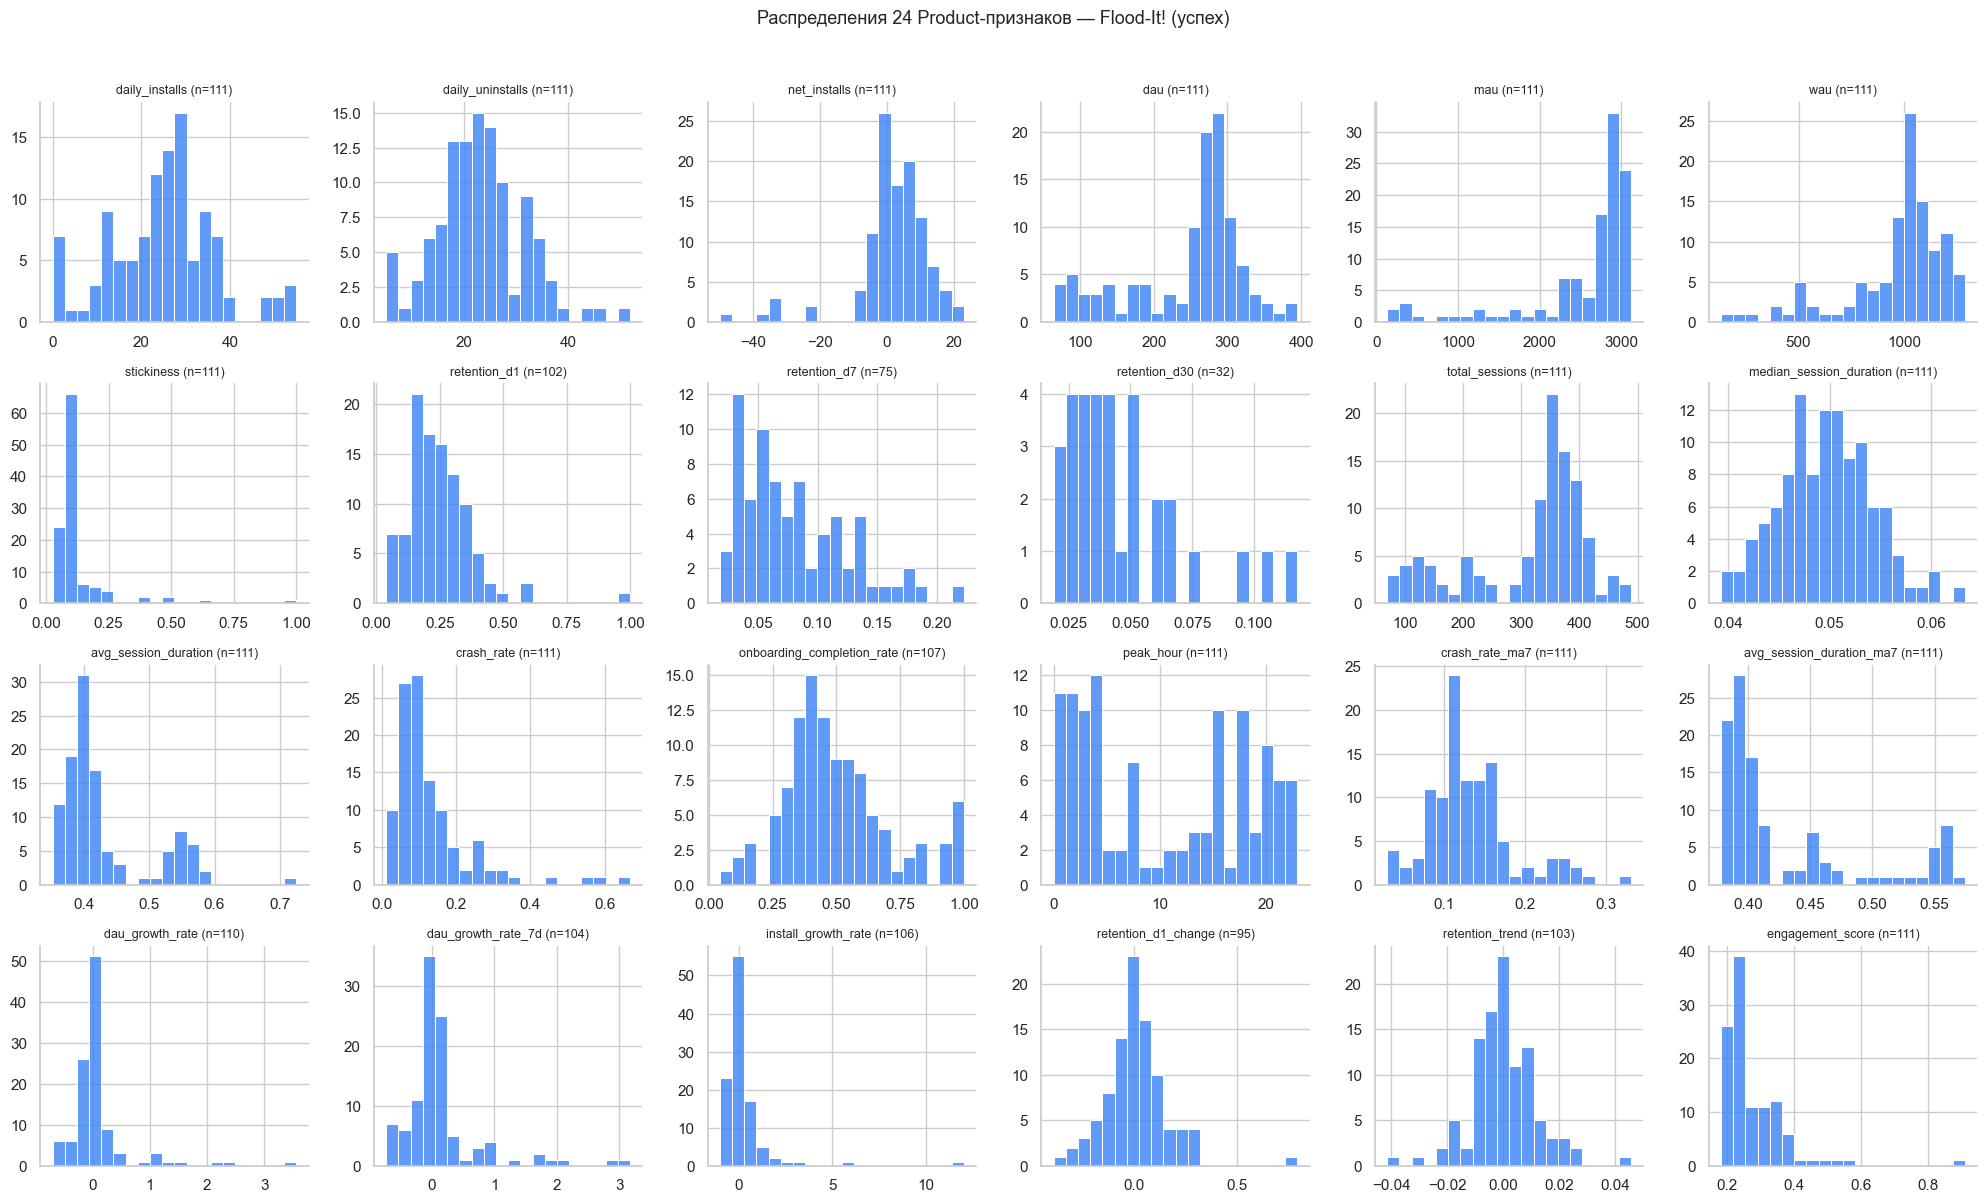

In [10]:
# Histograms grid 4×6 — single-color (синий = Flood-It!)
fig, axes = plt.subplots(4, 6, figsize=(20, 12))
for i, col in enumerate(PRODUCT_COLS):
    ax = axes.flat[i]
    s = df_f1[col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) > 0:
        sns.histplot(s, color=APP_PALETTE[APP_ID], bins=20, ax=ax, alpha=0.8, kde=False)
    ax.set_title(f"{col} (n={len(s)})", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle(f"Распределения 24 Product-признаков — {app_label(APP_ID)}", y=1.00, fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.98))
save_figure("histograms_product", NOTEBOOK_SLUG)
plt.show()

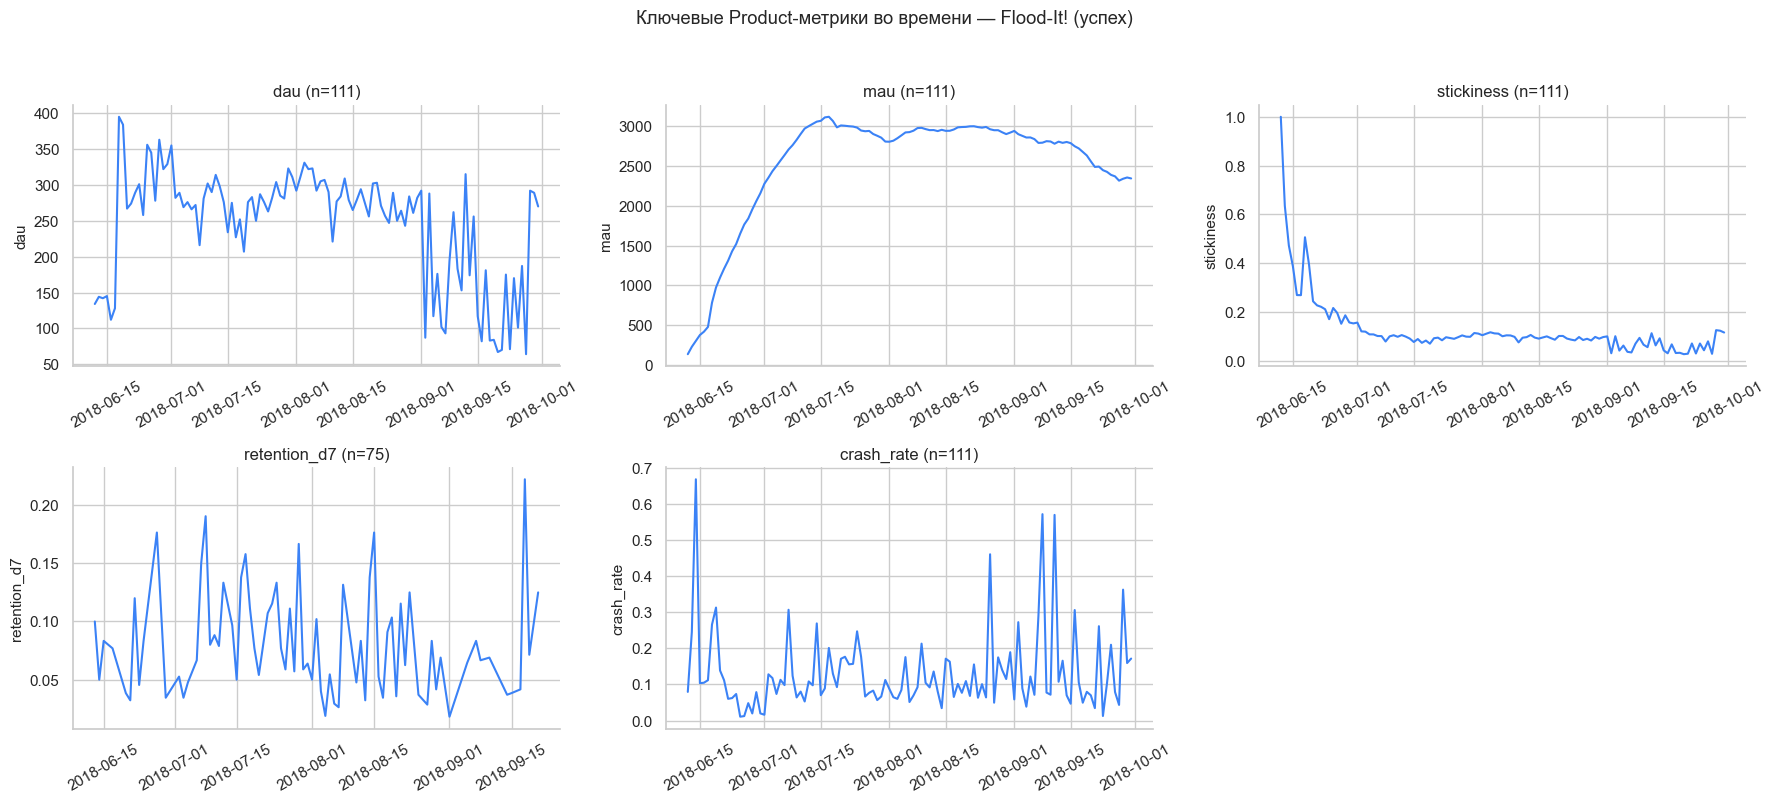

In [11]:
# Time series 5 ключевых
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
key_product = ["dau", "mau", "stickiness", "retention_d7", "crash_rate"]
for i, col in enumerate(key_product):
    ax = axes.flat[i]
    sns.lineplot(data=df_f1, x="date", y=col,
                 color=APP_PALETTE[APP_ID], ax=ax)
    ax.set_title(f"{col} (n={df_f1[col].notna().sum()})")
    ax.set_xlabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(30)
axes.flat[5].set_visible(False)
fig.suptitle(f"Ключевые Product-метрики во времени — {app_label(APP_ID)}", y=1.00)
plt.tight_layout(rect=(0, 0, 1, 0.97))
save_figure("timeseries_product", NOTEBOOK_SLUG)
plt.show()

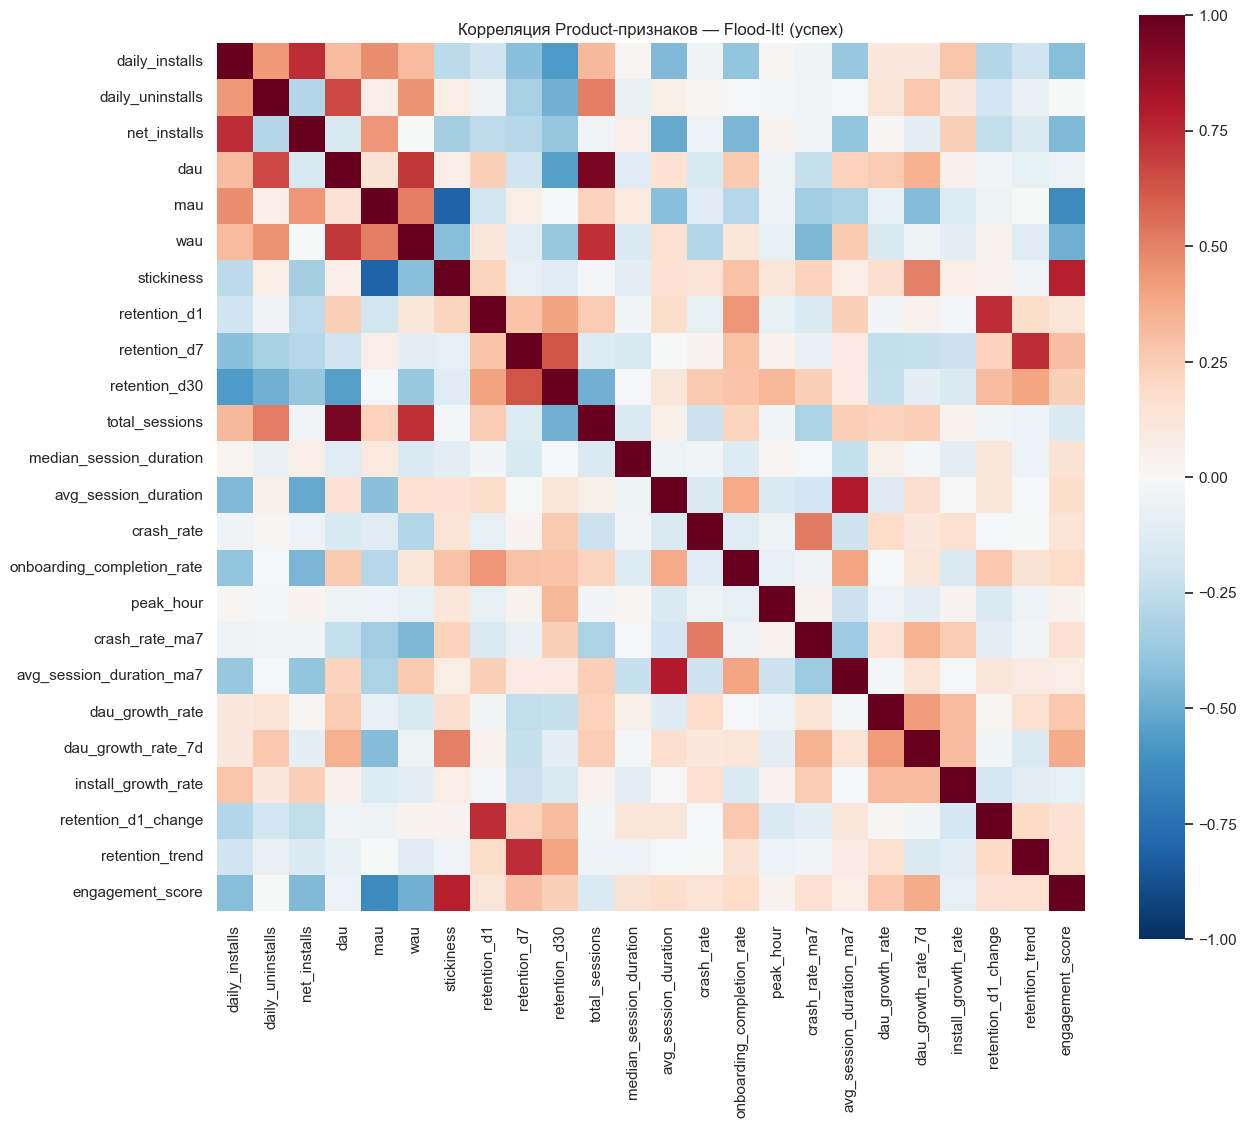

Топ-5 интра-Product пар |corr|>0.7:
dau                   total_sessions              0.949655
mau                   stickiness                 -0.810528
avg_session_duration  avg_session_duration_ma7    0.794280
stickiness            engagement_score            0.776692
retention_d7          retention_trend             0.739837
dtype: float64


In [12]:
# Intra-source corr heatmap для Product
fig, ax = plt.subplots(figsize=(14, 12))
corr_product = df_f1[PRODUCT_COLS].corr()
sns.heatmap(corr_product, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, square=True, ax=ax)
ax.set_title(f"Корреляция Product-признаков — {app_label(APP_ID)}")
save_figure("corr_product", NOTEBOOK_SLUG)
plt.show()
print("Топ-5 интра-Product пар |corr|>0.7:")
print(top_correlated_pairs(corr_product, threshold=0.7, n=5))

## 4. Section B — Store (Google Play) для Flood-It!

In [13]:
display(df_f1[STORE_COLS].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
rating,111.0,4.051,0.001,4.050,4.050,4.051,4.051,4.051
reviews_count,111.0,1955.793,1.912,1954.000,1954.000,1955.000,1957.500,1959.000
positive,111.0,1454.117,1.644,1453.000,1453.000,1453.000,1455.500,1457.000
negative,111.0,320.676,0.470,320.000,320.000,321.000,321.000,321.000
positive_ratio,111.0,0.743,0.000,0.743,0.743,0.744,0.744,0.744
sentiment_score,111.0,0.580,0.000,0.579,0.579,0.580,0.580,0.580
reviews_30d,111.0,1.261,1.346,0.000,0.000,1.000,2.000,4.000
positive_30d,111.0,0.991,1.468,0.000,0.000,0.000,2.000,4.000
negative_30d,111.0,0.270,0.446,0.000,0.000,0.000,1.000,1.000
sentiment_30d,70.0,0.143,0.997,-1.000,-1.000,1.000,1.000,1.000


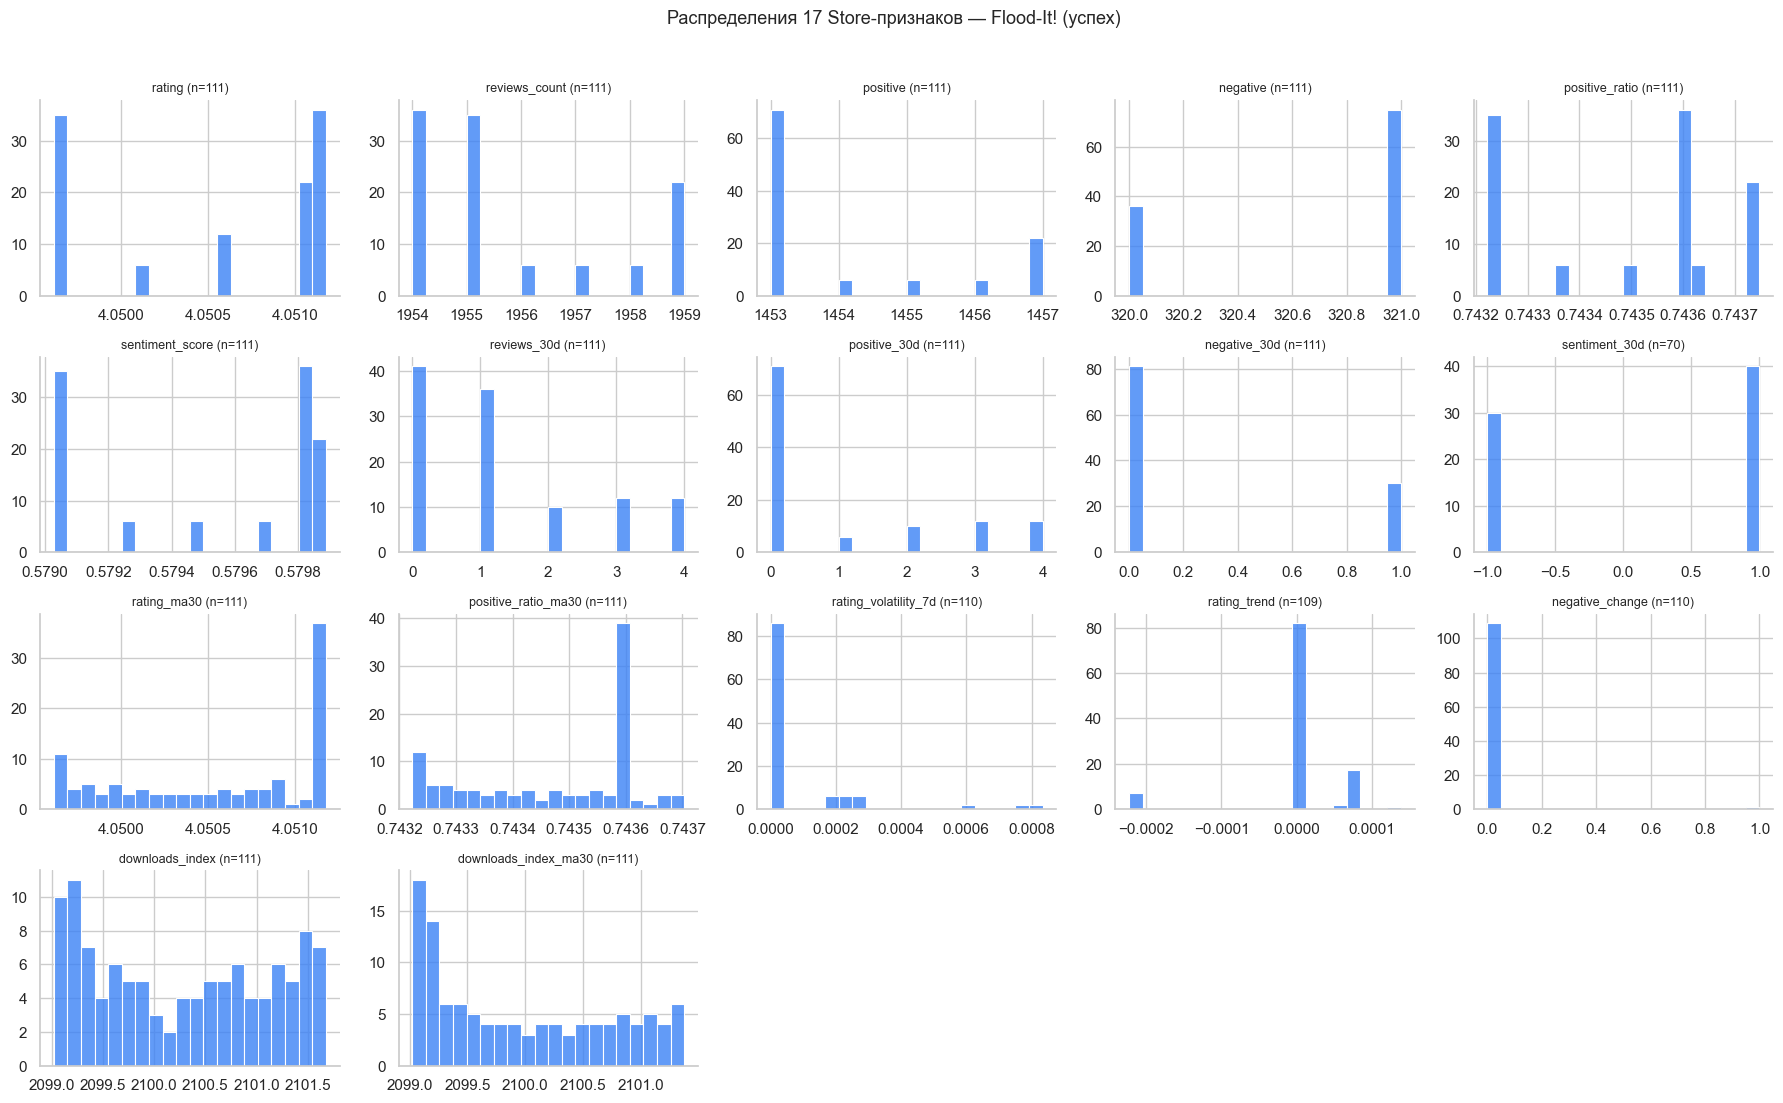

In [14]:
# Histograms grid 4×5 (последняя ячейка пустая)
fig, axes = plt.subplots(4, 5, figsize=(18, 11))
for i, col in enumerate(STORE_COLS):
    ax = axes.flat[i]
    s = df_f1[col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) > 0:
        sns.histplot(s, color=APP_PALETTE[APP_ID], bins=20, ax=ax, alpha=0.8, kde=False)
    ax.set_title(f"{col} (n={len(s)})", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
for j in range(len(STORE_COLS), 4 * 5):
    axes.flat[j].set_visible(False)
fig.suptitle(f"Распределения 17 Store-признаков — {app_label(APP_ID)}", y=1.00, fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.98))
save_figure("histograms_store", NOTEBOOK_SLUG)
plt.show()

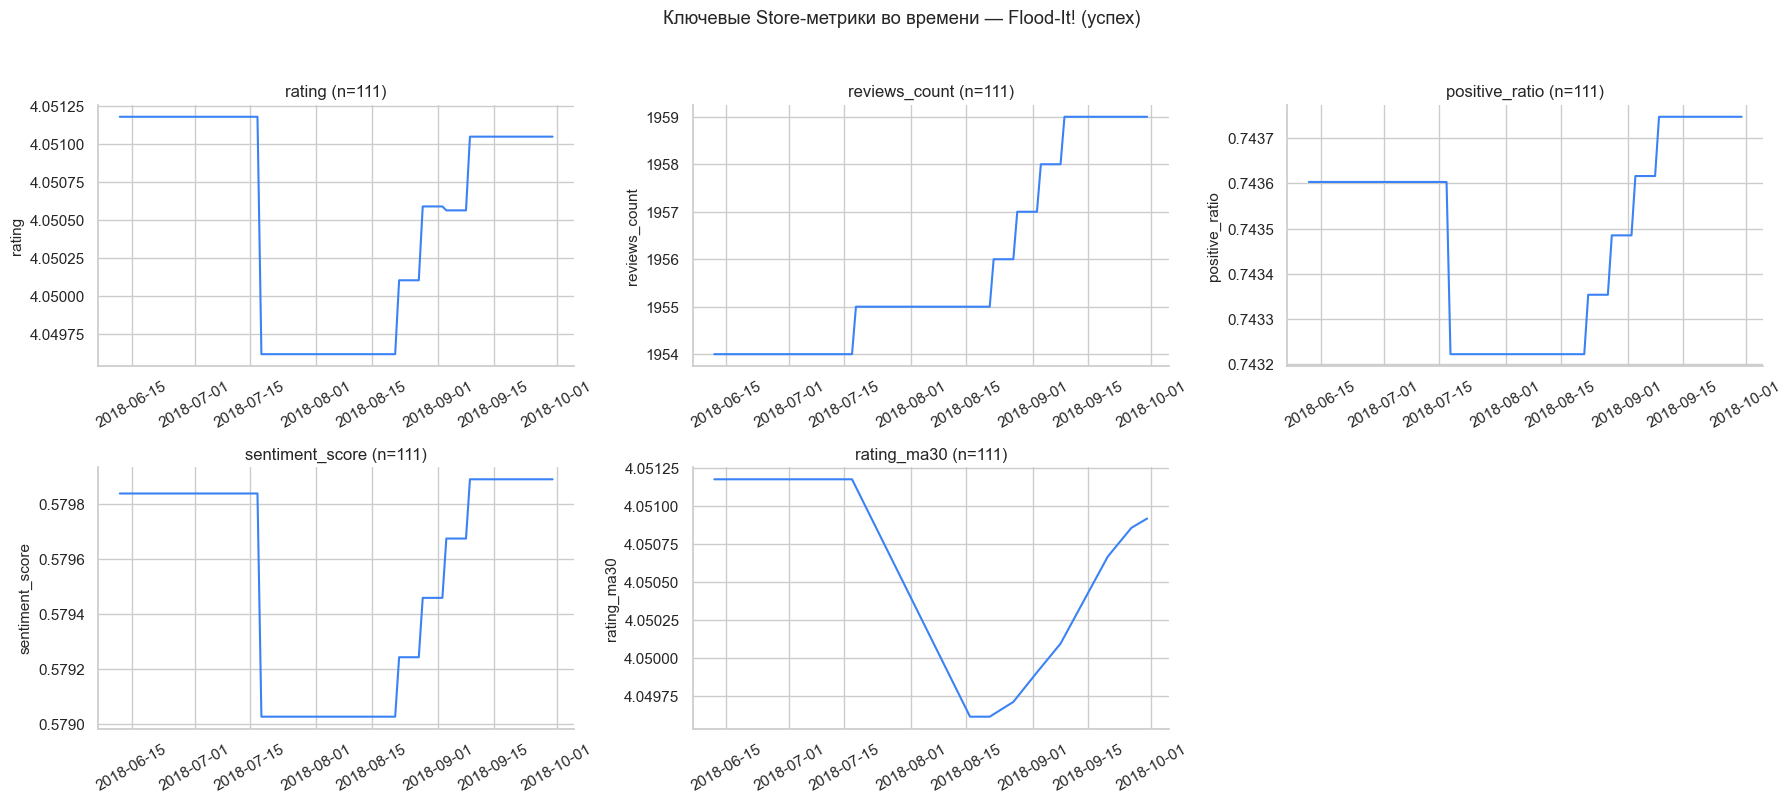

In [15]:
# Time series 5 ключевых store метрик
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
key_store = ["rating", "reviews_count", "positive_ratio", "sentiment_score", "rating_ma30"]
for i, col in enumerate(key_store):
    ax = axes.flat[i]
    sns.lineplot(data=df_f1, x="date", y=col,
                 color=APP_PALETTE[APP_ID], ax=ax)
    ax.set_title(f"{col} (n={df_f1[col].notna().sum()})")
    ax.set_xlabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(30)
axes.flat[5].set_visible(False)
fig.suptitle(f"Ключевые Store-метрики во времени — {app_label(APP_ID)}", y=1.00)
plt.tight_layout(rect=(0, 0, 1, 0.97))
save_figure("timeseries_store", NOTEBOOK_SLUG)
plt.show()

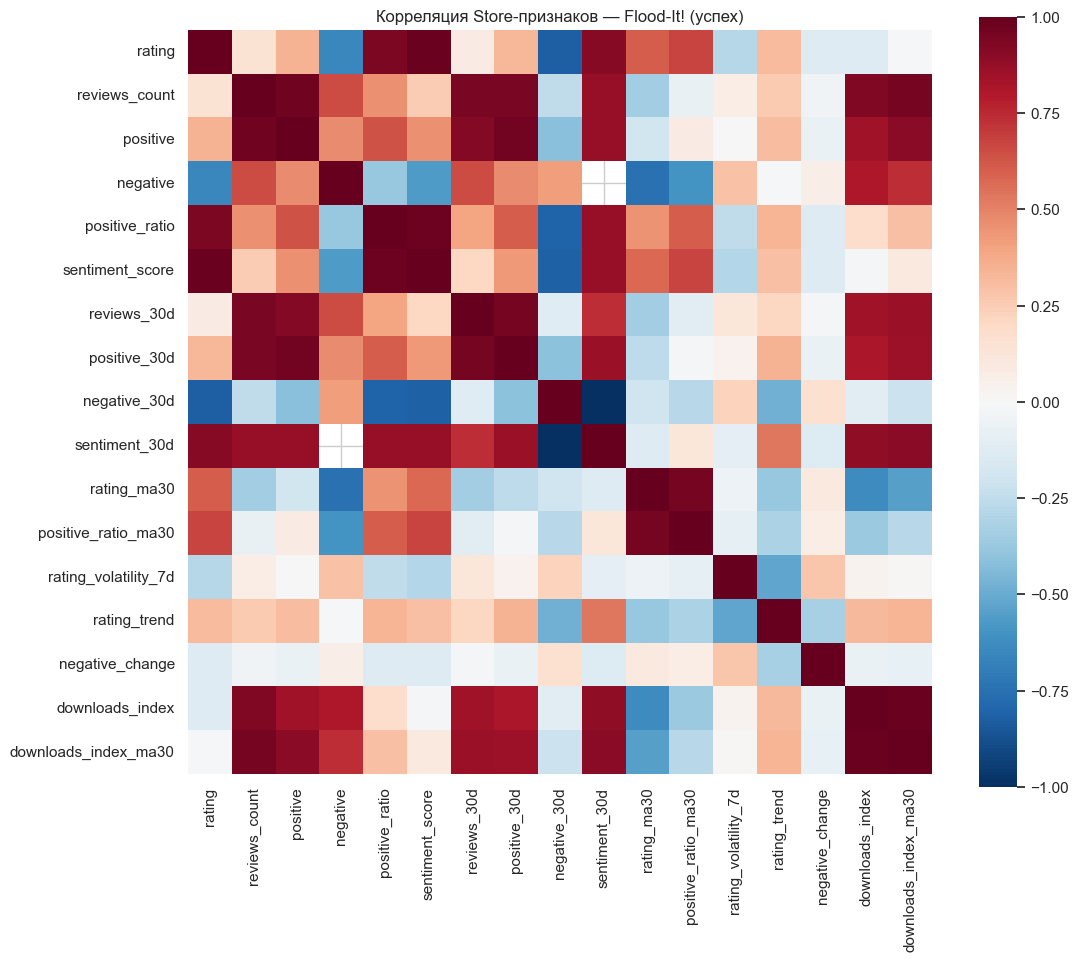

Топ-5 интра-Store пар |corr|>0.7:
negative_30d     sentiment_30d          -1.000000
downloads_index  downloads_index_ma30    0.990349
rating           sentiment_score         0.987758
positive_ratio   sentiment_score         0.977008
reviews_count    positive                0.976240
dtype: float64


In [16]:
# Intra-source corr heatmap для Store
fig, ax = plt.subplots(figsize=(12, 10))
corr_store = df_f1[STORE_COLS].corr()
sns.heatmap(corr_store, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, square=True, ax=ax)
ax.set_title(f"Корреляция Store-признаков — {app_label(APP_ID)}")
save_figure("corr_store", NOTEBOOK_SLUG)
plt.show()
print("Топ-5 интра-Store пар |corr|>0.7:")
print(top_correlated_pairs(corr_store, threshold=0.7, n=5))

## 5. Section C — Market (краткий референс)

Market-метрики (`competitor_count`, `category_rank`, их MA и волатильности) **общие для обоих приложений** — обе игры в одной категории Google Play (puzzle), и значения собираются для категории целиком, а не для отдельного приложения. Полный анализ Market-группы — в `01_source_market.ipynb`.

Здесь приводим только один time-series график для контекста: как меняется конкурентная среда у Flood-It! за период наблюдений.

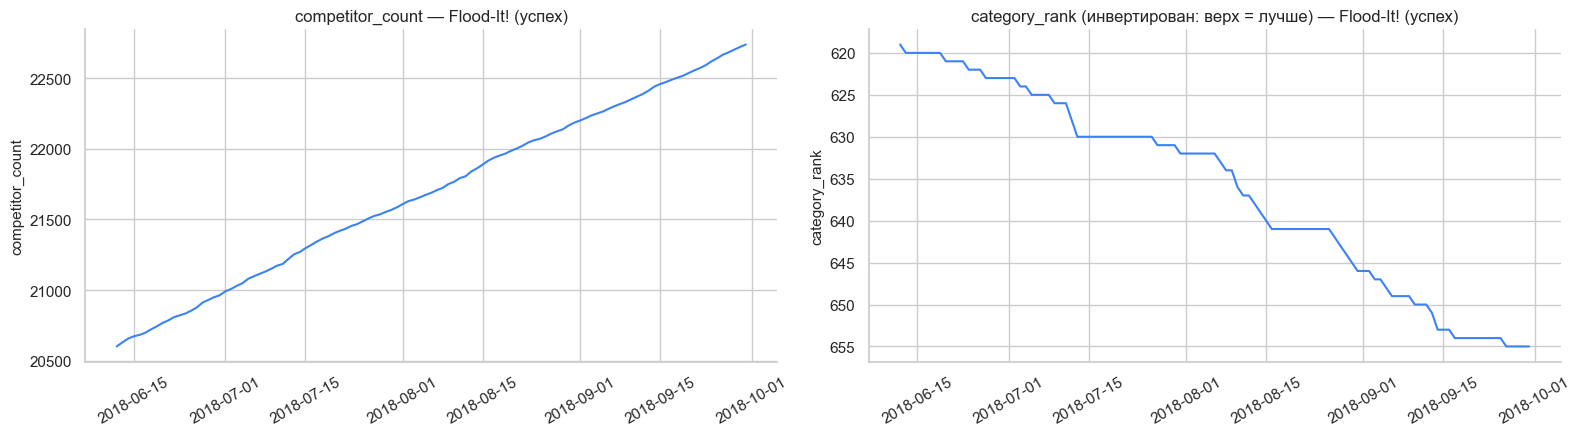

competitor_count: median=21688.0, std=620.40
category_rank: median=632.0, std=11.58


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.lineplot(data=df_f1, x="date", y="competitor_count",
             color=APP_PALETTE[APP_ID], ax=axes[0])
axes[0].set_title(f"competitor_count — {app_label(APP_ID)}")
axes[0].set_xlabel("")
sns.lineplot(data=df_f1, x="date", y="category_rank",
             color=APP_PALETTE[APP_ID], ax=axes[1])
axes[1].invert_yaxis()  # rank: 1 = top, инвертируем для визуальной интуиции
axes[1].set_title(f"category_rank (инвертирован: верх = лучше) — {app_label(APP_ID)}")
axes[1].set_xlabel("")
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(30)
plt.tight_layout()
save_figure("timeseries_market_for_f1", NOTEBOOK_SLUG)
plt.show()
print(f"competitor_count: median={df_f1['competitor_count'].median()}, "
      f"std={df_f1['competitor_count'].std():.2f}")
print(f"category_rank: median={df_f1['category_rank'].median()}, "
      f"std={df_f1['category_rank'].std():.2f}")

## 6. Section D — External (краткий референс)

External-метрики (`market_trend`, `media_coverage`, `market_sentiment`, MA и change-производные) отражают **внешний фон рынка** — Google Trends, медиа-упоминания, сезонность. Эти значения общие для обоих приложений (рынок один). Полный анализ — в `01_source_external.ipynb`.

Здесь приводим один time-series для контекста.

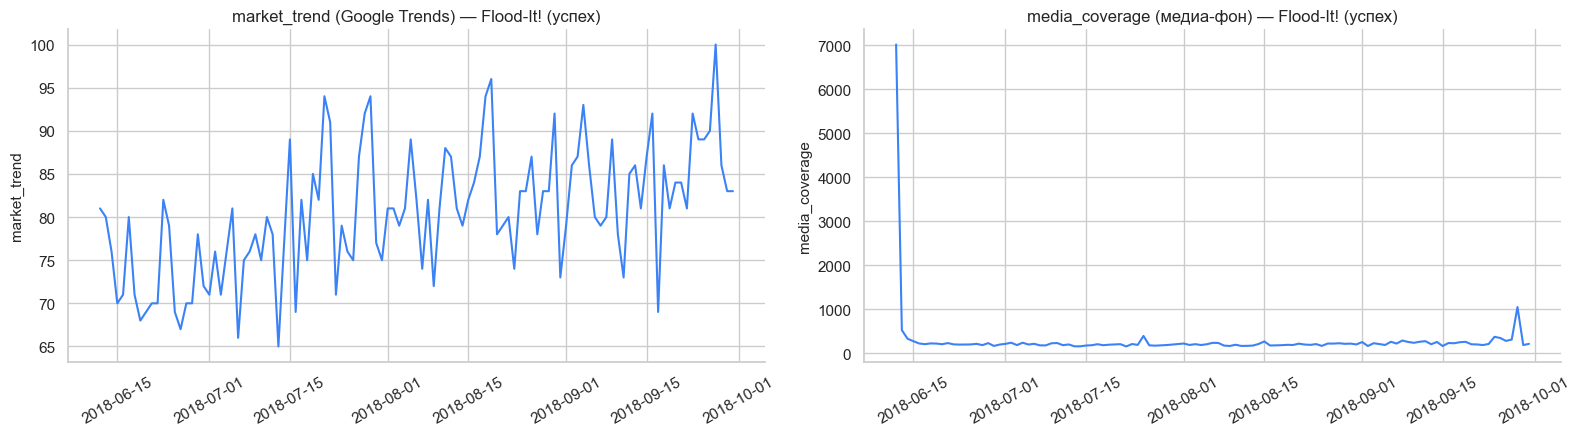

market_trend: median=81.000, std=7.384
media_coverage: median=205.000, std=651.920


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.lineplot(data=df_f1, x="date", y="market_trend",
             color=APP_PALETTE[APP_ID], ax=axes[0])
axes[0].set_title(f"market_trend (Google Trends) — {app_label(APP_ID)}")
axes[0].set_xlabel("")
sns.lineplot(data=df_f1, x="date", y="media_coverage",
             color=APP_PALETTE[APP_ID], ax=axes[1])
axes[1].set_title(f"media_coverage (медиа-фон) — {app_label(APP_ID)}")
axes[1].set_xlabel("")
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(30)
plt.tight_layout()
save_figure("timeseries_external_for_f1", NOTEBOOK_SLUG)
plt.show()
print(f"market_trend: median={df_f1['market_trend'].median():.3f}, "
      f"std={df_f1['market_trend'].std():.3f}")
print(f"media_coverage: median={df_f1['media_coverage'].median():.3f}, "
      f"std={df_f1['media_coverage'].std():.3f}")

## 7. ⭐ Cross-source synthesis — главный вклад этого ноутбука

Здесь мы смотрим **что коррелирует между источниками** — где Product-метрики связаны со Store-репутацией, как Market-фон влияет на поведение пользователей, и т. д. Это уникальное представление **полного feature-вектора** глазами модели.

### 7.1. Полная корр. матрица 55×55 со source-разделителями

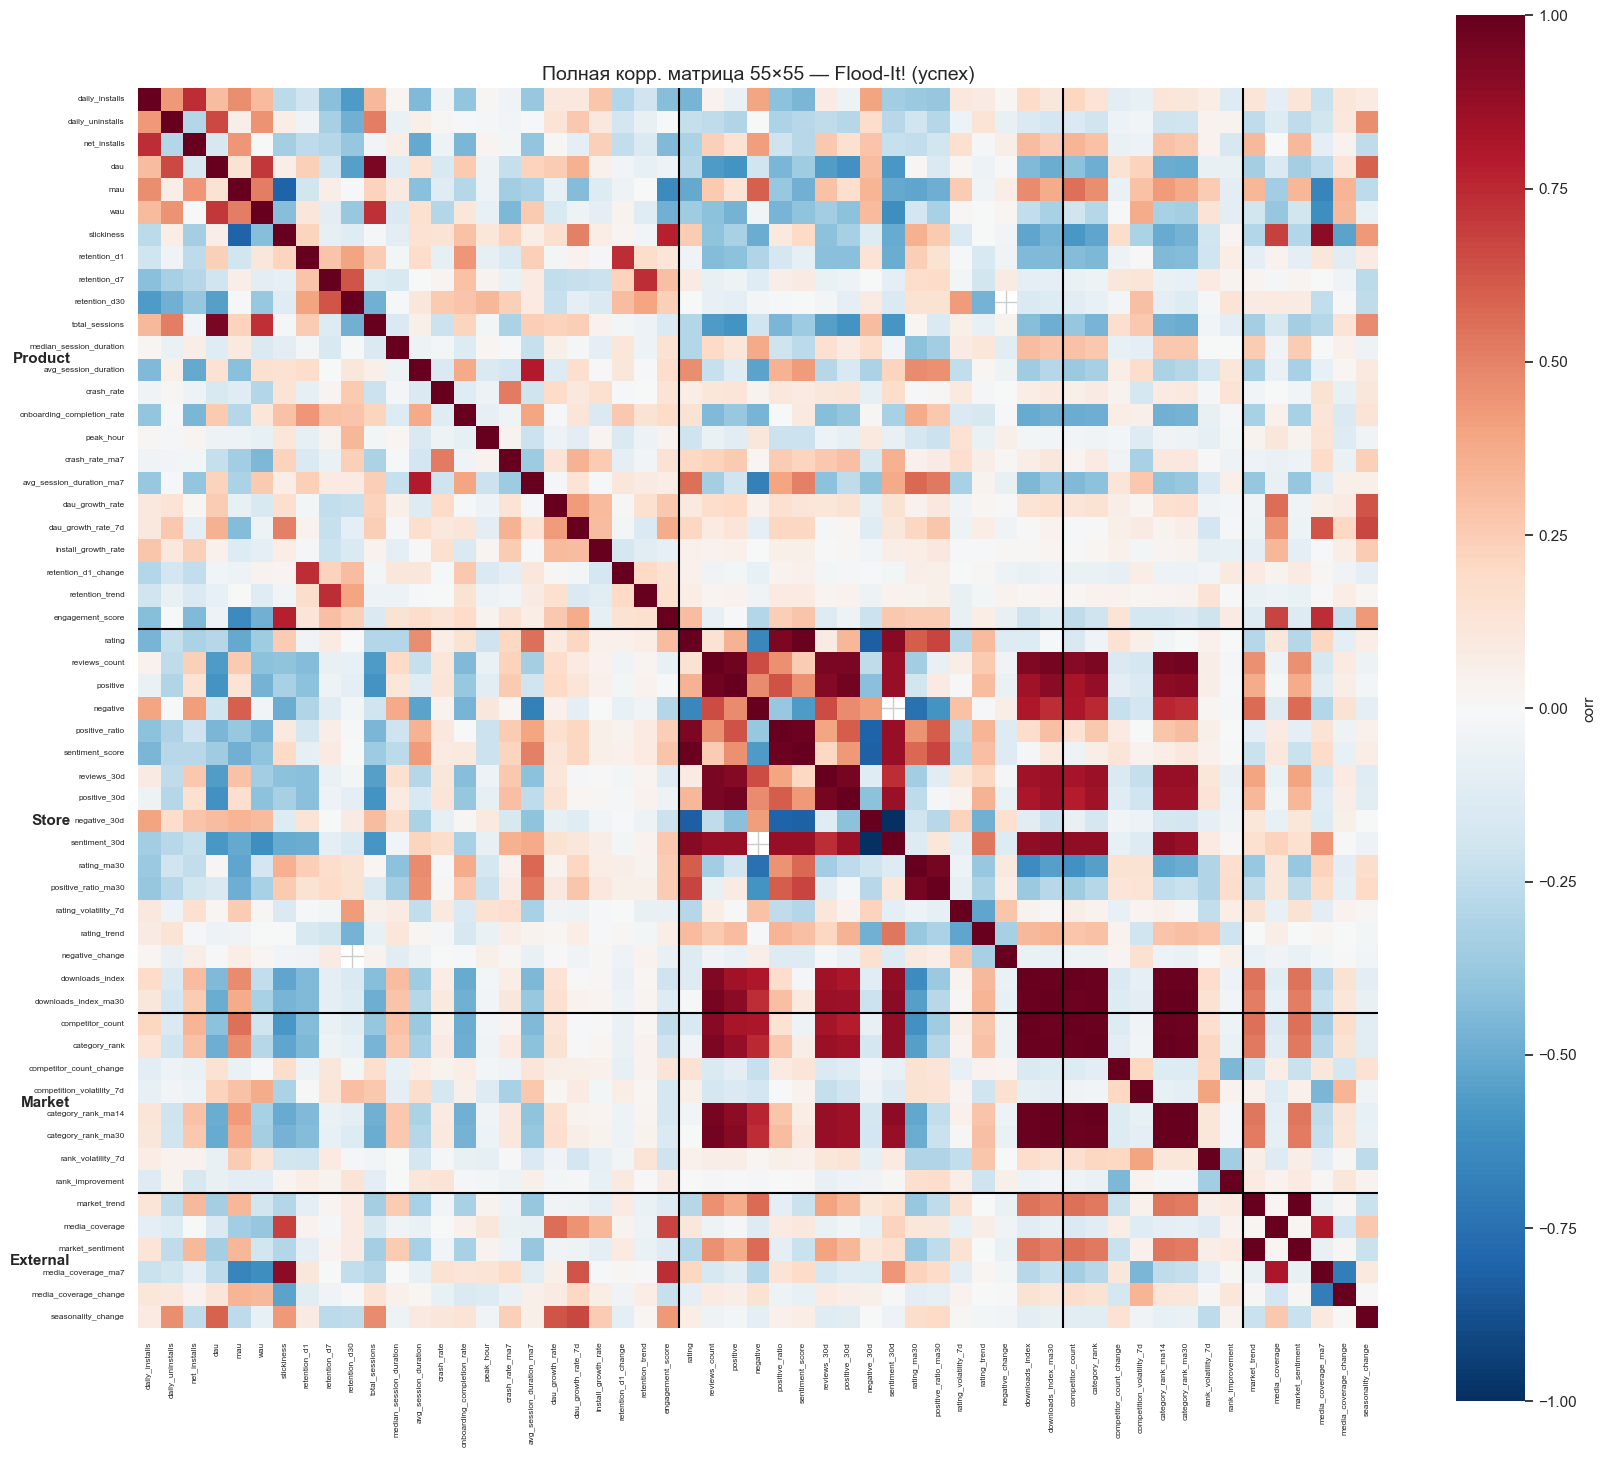

In [19]:
fig, ax = plt.subplots(figsize=(20, 18))
corr_full = df_f1[ALL_FEATURE_COLS].corr()
sns.heatmap(corr_full, cmap="RdBu_r", center=0, annot=False, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={"label": "corr"},
            xticklabels=ALL_FEATURE_COLS, yticklabels=ALL_FEATURE_COLS)
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.tick_params(axis="y", labelsize=6)

# Source-group separators + аннотации групп (для печати)
group_boundaries = [
    len(PRODUCT_COLS),
    len(PRODUCT_COLS) + len(STORE_COLS),
    len(PRODUCT_COLS) + len(STORE_COLS) + len(MARKET_COLS),
]
group_centers = [
    len(PRODUCT_COLS) / 2,
    len(PRODUCT_COLS) + len(STORE_COLS) / 2,
    len(PRODUCT_COLS) + len(STORE_COLS) + len(MARKET_COLS) / 2,
    len(PRODUCT_COLS) + len(STORE_COLS) + len(MARKET_COLS) + len(EXTERNAL_COLS) / 2,
]
group_names = ["Product", "Store", "Market", "External"]

for boundary in group_boundaries:
    ax.axhline(boundary, color="black", linewidth=1.5)
    ax.axvline(boundary, color="black", linewidth=1.5)

# Подписи групп на левой оси (выше)
for center, name in zip(group_centers, group_names):
    ax.text(-3, center, name, ha="right", va="center", fontsize=11, fontweight="bold")

ax.set_title(f"Полная корр. матрица {len(ALL_FEATURE_COLS)}×{len(ALL_FEATURE_COLS)} — {app_label(APP_ID)}",
             fontsize=14)
save_figure("corr_full_55x55", NOTEBOOK_SLUG)
plt.show()

### 7.2. Сокращённая корр. матрица 20 ключевых признаков

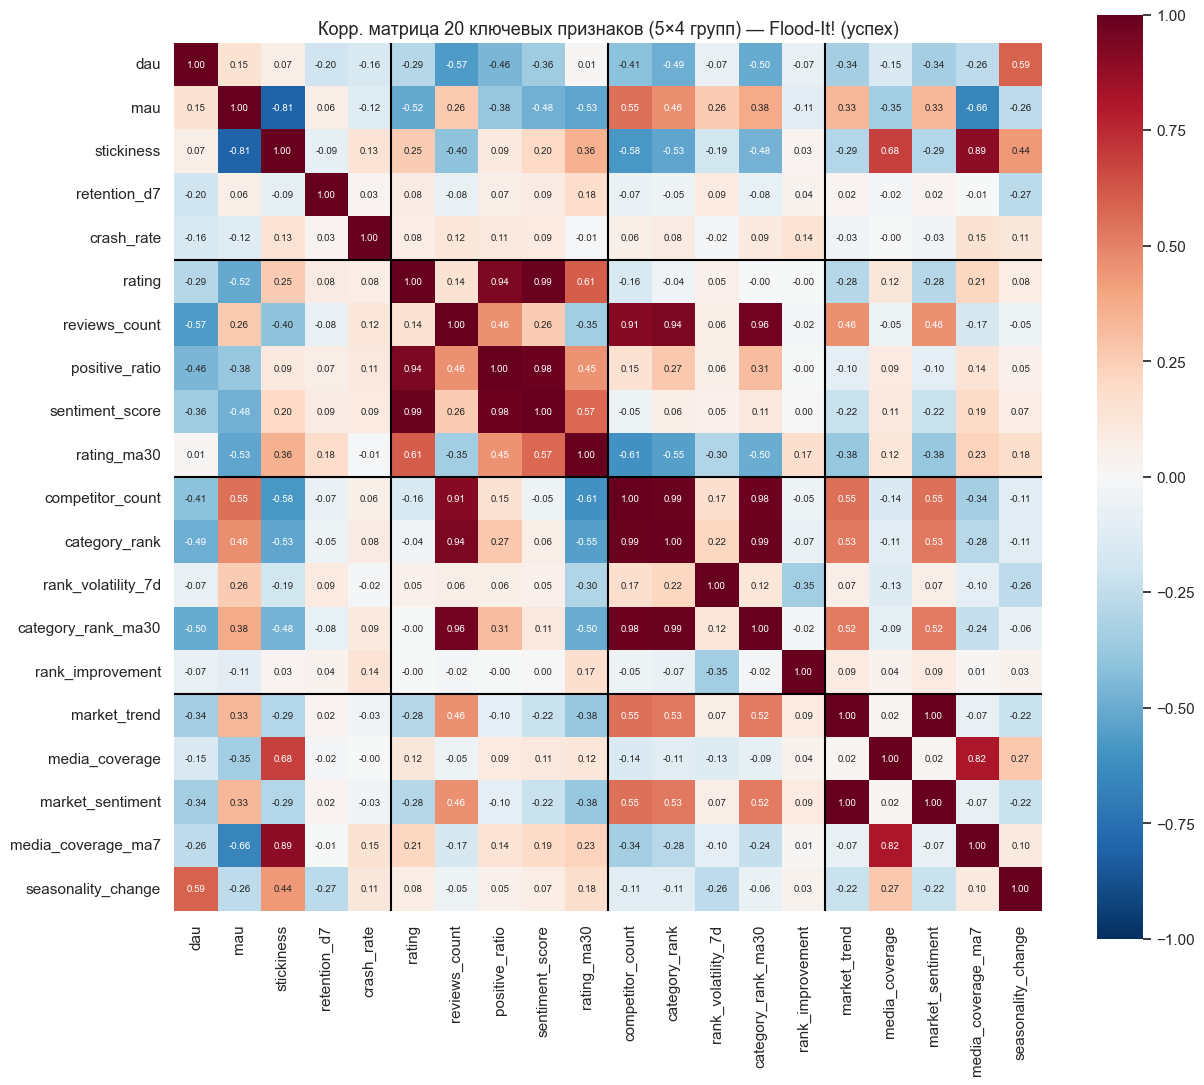

In [20]:
# 5 ключевых из каждой группы (бизнес-важность)
KEY_PRODUCT = ["dau", "mau", "stickiness", "retention_d7", "crash_rate"]
KEY_STORE   = ["rating", "reviews_count", "positive_ratio", "sentiment_score", "rating_ma30"]
KEY_MARKET  = ["competitor_count", "category_rank", "rank_volatility_7d", "category_rank_ma30", "rank_improvement"]
KEY_EXTERNAL = ["market_trend", "media_coverage", "market_sentiment", "media_coverage_ma7", "seasonality_change"]
KEY_20 = KEY_PRODUCT + KEY_STORE + KEY_MARKET + KEY_EXTERNAL
assert len(KEY_20) == 20

fig, ax = plt.subplots(figsize=(14, 12))
corr_key = df_f1[KEY_20].corr()
sns.heatmap(corr_key, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            vmin=-1, vmax=1, square=True, ax=ax,
            annot_kws={"size": 7})
group_boundaries_k = [5, 10, 15]
for boundary in group_boundaries_k:
    ax.axhline(boundary, color="black", linewidth=1.5)
    ax.axvline(boundary, color="black", linewidth=1.5)
ax.set_title(f"Корр. матрица 20 ключевых признаков (5×4 групп) — {app_label(APP_ID)}",
             fontsize=13)
save_figure("corr_key_20x20", NOTEBOOK_SLUG)
plt.show()

### 7.3. VIF-анализ — мультиколлинеарность по 55 признакам

In [21]:
# Заполняем NaN медианой для VIF — без этого compute_vif даёт меньше колонок
df_f1_filled = df_f1[ALL_FEATURE_COLS].replace([np.inf, -np.inf], np.nan).copy()
df_f1_filled = df_f1_filled.fillna(df_f1_filled.median(numeric_only=True))

vif_df = compute_vif(df_f1_filled)
print(f"Признаков всего: {len(vif_df)}")
print(f"С VIF > 10 (мультиколлинеарных): {(~vif_df['keep']).sum()}")
print(f"С VIF <= 10 (приемлемых):       {vif_df['keep'].sum()}")
display(vif_df.head(20))

Признаков всего: 55
С VIF > 10 (мультиколлинеарных): 34
С VIF <= 10 (приемлемых):       21


,feature,vif,keep
0,daily_installs,1.000000e+09,False
1,daily_uninstalls,1.000000e+09,False
2,net_installs,1.000000e+09,False
3,negative,1.000000e+09,False
4,reviews_30d,1.000000e+09,False
5,reviews_count,1.000000e+09,False
6,positive,1.000000e+09,False
7,market_sentiment,1.000000e+09,False
8,positive_30d,1.000000e+09,False
9,sentiment_30d,1.000000e+09,False


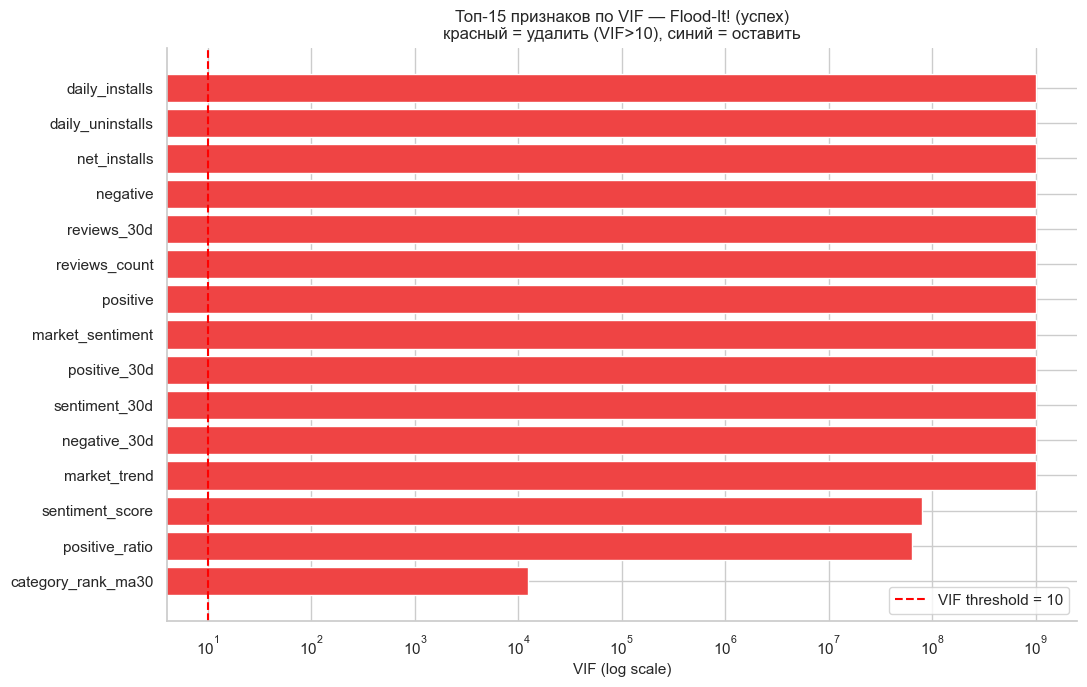

In [22]:
# Bar chart топ-15 по VIF (красные = мультиколлинеарные)
fig, ax = plt.subplots(figsize=(11, 7))
top15 = vif_df.head(15).copy()
colors = ["#ef4444" if not k else "#3b82f6" for k in top15["keep"]]
y = top15["feature"][::-1].values
x = top15["vif"][::-1].values
c = colors[::-1]
ax.barh(y, x, color=c)
ax.axvline(10, color="red", linestyle="--", label="VIF threshold = 10")
ax.set_xlabel("VIF (log scale)")
ax.set_xscale("log")
ax.set_title(f"Топ-15 признаков по VIF — {app_label(APP_ID)}\n"
             f"красный = удалить (VIF>10), синий = оставить")
ax.legend(loc="lower right")
plt.tight_layout()
save_figure("vif_top15", NOTEBOOK_SLUG)
plt.show()

### 7.4. Топ-15 cross-source пар

In [23]:
def assign_group(col):
    for group, cols in SOURCE_GROUPS.items():
        if col in cols:
            return group
    return "Other"

cross_source_pairs = []
for c1, c2 in itertools.combinations(ALL_FEATURE_COLS, 2):
    g1, g2 = assign_group(c1), assign_group(c2)
    if g1 != g2 and g1 != "Other" and g2 != "Other":
        r = corr_full.loc[c1, c2]
        if pd.notna(r) and abs(r) > 0.3:
            cross_source_pairs.append({
                "feat1": c1, "group1": g1,
                "feat2": c2, "group2": g2,
                "corr": round(float(r), 3),
            })

pairs_df = (
    pd.DataFrame(cross_source_pairs)
    .sort_values("corr", key=lambda s: s.abs(), ascending=False)
    .head(15)
    .reset_index(drop=True)
)
print(f"Всего cross-source пар с |corr|>0.3: {len(cross_source_pairs)}")
print(f"Топ-15:")
display(pairs_df)

Всего cross-source пар с |corr|>0.3: 249
Топ-15:


,feat1,group1,feat2,group2,corr
0,downloads_index_ma30,Store,category_rank_ma30,Market,0.997
1,downloads_index,Store,competitor_count,Market,0.994
2,downloads_index_ma30,Store,category_rank_ma14,Market,0.994
3,downloads_index,Store,category_rank,Market,0.991
4,downloads_index_ma30,Store,category_rank,Market,0.990
5,downloads_index,Store,category_rank_ma14,Market,0.988
6,downloads_index,Store,category_rank_ma30,Market,0.985
7,downloads_index_ma30,Store,competitor_count,Market,0.978
8,reviews_count,Store,category_rank_ma30,Market,0.964
9,reviews_count,Store,category_rank_ma14,Market,0.957


In [24]:
# Распределение всех 249 cross-source пар по парам групп — для честного нарратива в §9
all_pairs_df = pd.DataFrame(cross_source_pairs)
group_breakdown = all_pairs_df.groupby(["group1", "group2"]).agg(
    count=("corr", "size"),
    max_abs_corr=("corr", lambda x: x.abs().max()),
    mean_abs_corr=("corr", lambda x: x.abs().mean()),
).round(3).sort_values("count", ascending=False)
display(group_breakdown)
print(f"\nИтого cross-source пар с |corr|>0.3: {len(all_pairs_df)}")

count  max_abs_corr  mean_abs_corr
group1  group2                                      
Product Store       109         0.686          0.433
Store   Market       39         0.997          0.814
Product Market       37         0.584          0.433
        External     36         0.895          0.461
Store   External     17         0.565          0.446
Market  External     11         0.554          0.491


Итого cross-source пар с |corr|>0.3: 249


### 7.5. Scatter plots топ-6 cross-source пар

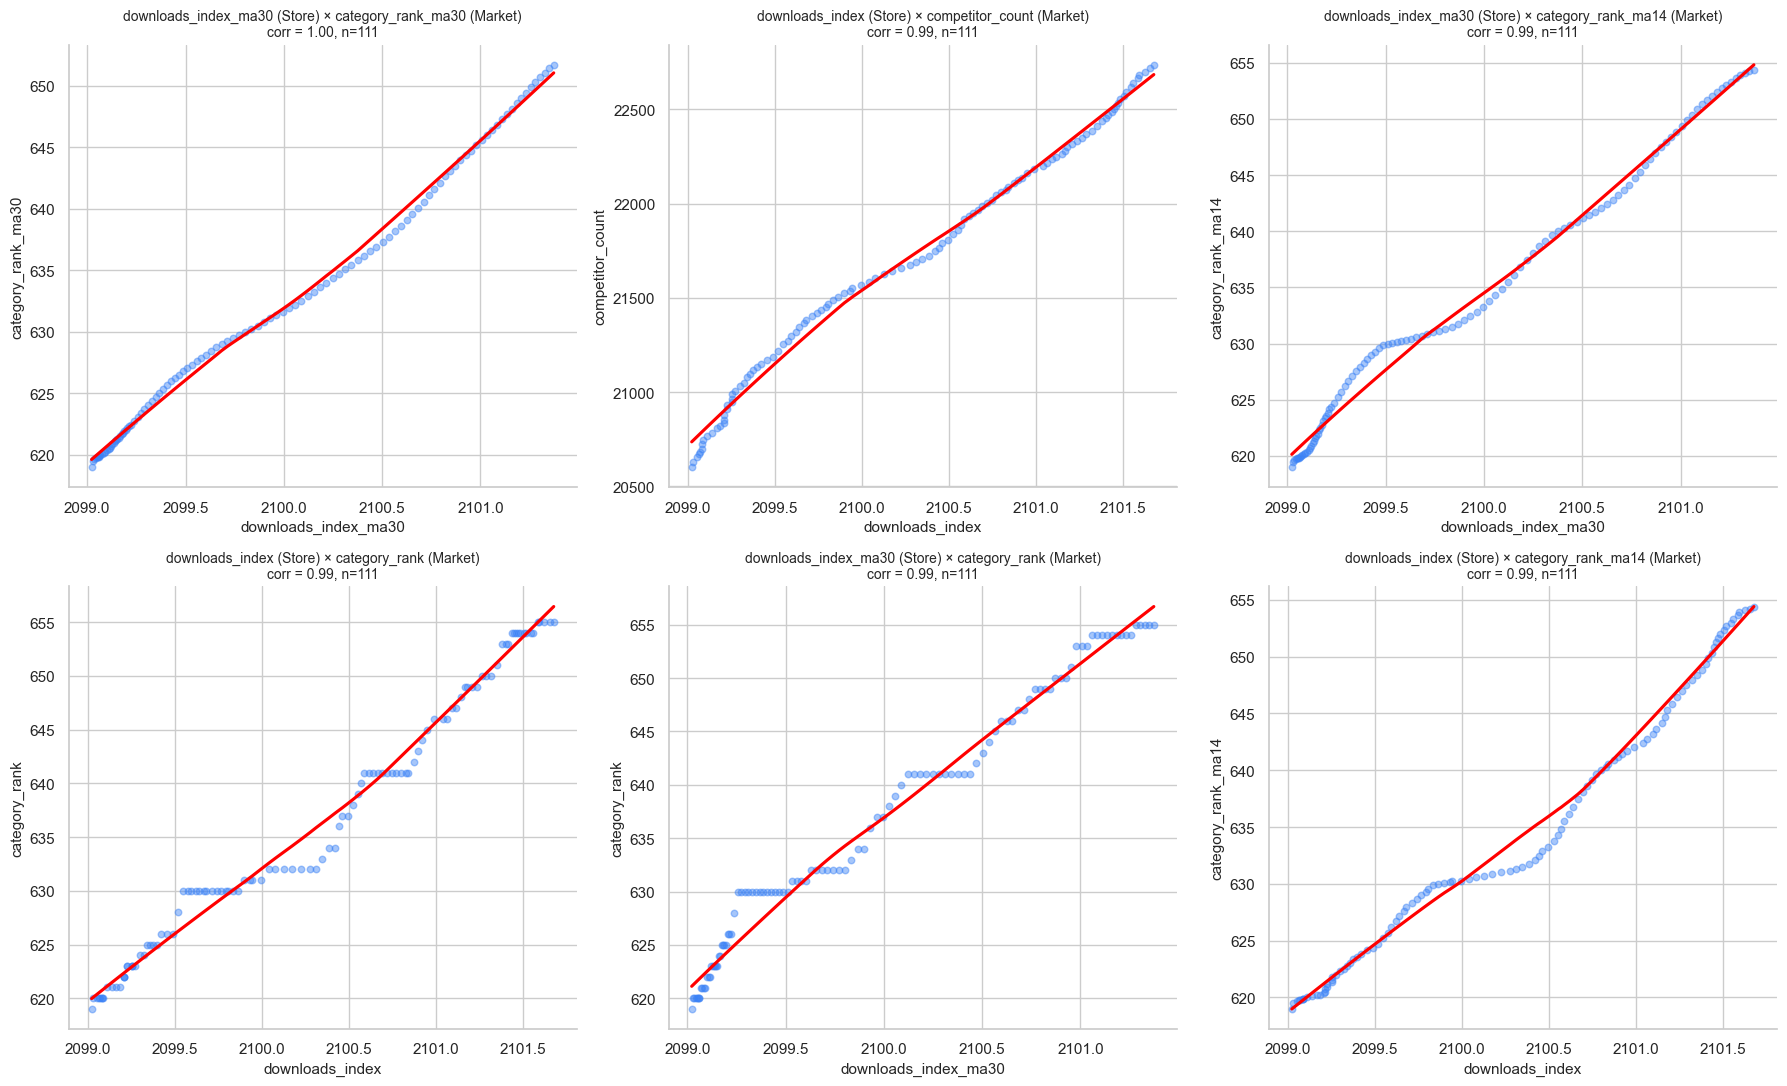

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
top6 = pairs_df.head(6).reset_index(drop=True)
for i, row in top6.iterrows():
    ax = axes.flat[i]
    sub = df_f1[[row["feat1"], row["feat2"]]].replace([np.inf, -np.inf], np.nan).dropna()
    sns.regplot(data=sub, x=row["feat1"], y=row["feat2"],
                lowess=True, scatter_kws={"alpha": 0.45, "s": 22, "color": APP_PALETTE[APP_ID]},
                line_kws={"color": "red"}, ax=ax)
    ax.set_title(f"{row['feat1']} ({row['group1']}) × {row['feat2']} ({row['group2']})\n"
                 f"corr = {row['corr']:.2f}, n={len(sub)}",
                 fontsize=10)
plt.tight_layout()
save_figure("scatter_top6_cross_source", NOTEBOOK_SLUG)
plt.show()

### 7.6. Pairplot 6 ключевых таргет-метрик

Pairplot rows after dropna: 75/111


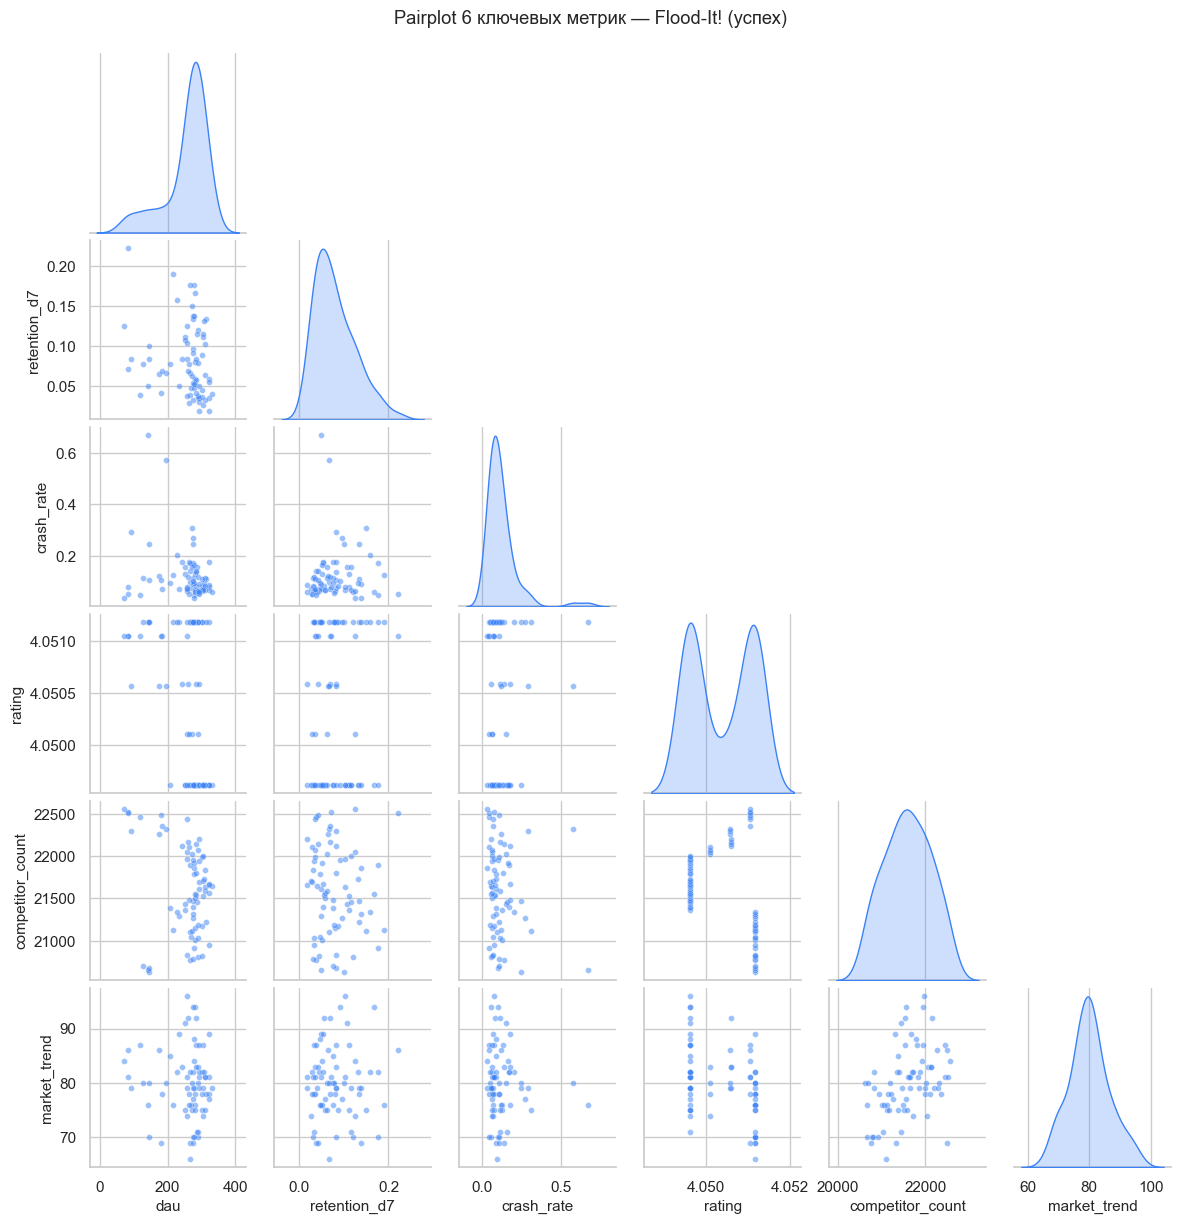

In [26]:
key6 = ["dau", "retention_d7", "crash_rate", "rating", "competitor_count", "market_trend"]
df_pair = df_f1[key6].replace([np.inf, -np.inf], np.nan).dropna()
print(f"Pairplot rows after dropna: {len(df_pair)}/{len(df_f1)}")
g = sns.pairplot(df_pair, diag_kind="kde", height=2.0,
                 plot_kws={"alpha": 0.5, "s": 18, "color": APP_PALETTE[APP_ID]},
                 diag_kws={"color": APP_PALETTE[APP_ID]},
                 corner=True)
g.fig.suptitle(f"Pairplot 6 ключевых метрик — {app_label(APP_ID)}", y=1.02)
save_figure("pairplot_key6", NOTEBOOK_SLUG, fig=g.fig)
plt.show()

## 8. Объединённый time-series 5 ключевых метрик

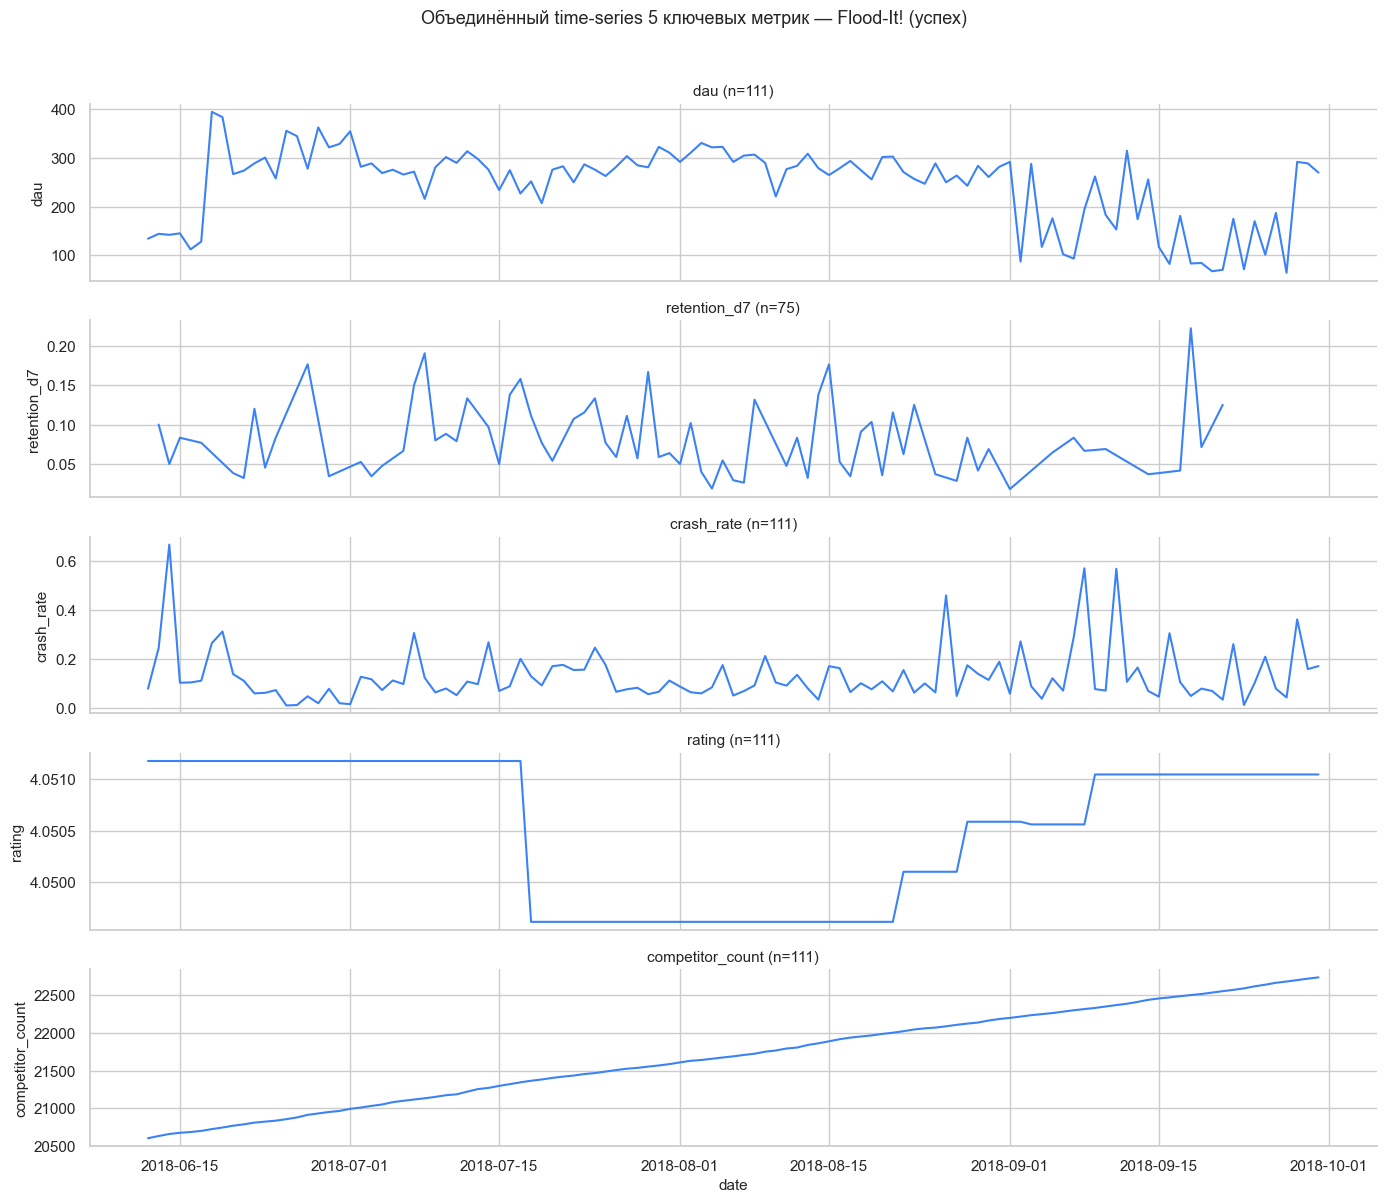

In [27]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
metrics = ["dau", "retention_d7", "crash_rate", "rating", "competitor_count"]
for i, m in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_f1, x="date", y=m, color=APP_PALETTE[APP_ID], ax=ax)
    ax.set_title(f"{m} (n={df_f1[m].notna().sum()})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel(m)
axes[-1].set_xlabel("date")
fig.suptitle(f"Объединённый time-series 5 ключевых метрик — {app_label(APP_ID)}",
             y=1.00, fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.98))
save_figure("unified_timeseries", NOTEBOOK_SLUG)
plt.show()

## 9. Выводы для Flood-It!

In [28]:
# Сводка реальных чисел для выводов
summary = {
    "dau_median": df_f1["dau"].median(),
    "dau_std": df_f1["dau"].std(),
    "stickiness_median": df_f1["stickiness"].median(),
    "retention_d7_median": df_f1["retention_d7"].median(),
    "retention_d7_n": df_f1["retention_d7"].notna().sum(),
    "crash_rate_median": df_f1["crash_rate"].median(),
    "crash_rate_pct_above_2pct": (df_f1["crash_rate"] > 0.02).mean() * 100,
    "rating_median": df_f1["rating"].median(),
    "rating_volatility_median": df_f1["rating_volatility_7d"].median(),
    "positive_ratio_median": df_f1["positive_ratio"].median(),
    "competitor_count_median": df_f1["competitor_count"].median(),
    "category_rank_median": df_f1["category_rank"].median(),
    "vif_high_count": int((~vif_df["keep"]).sum()),
    "vif_keep_count": int(vif_df["keep"].sum()),
    "n_cross_source_pairs_above_0_3": len(cross_source_pairs),
    "top_pair": (pairs_df.iloc[0]["feat1"], pairs_df.iloc[0]["feat2"], pairs_df.iloc[0]["corr"]),
}
for k, v in summary.items():
    print(f"{k}: {v}")

dau_median: 275.0
dau_std: 78.65110758277169
stickiness_median: 0.09702767338571916
retention_d7_median: 0.06896551724137931
retention_d7_n: 75
crash_rate_median: 0.09831460674157304
crash_rate_pct_above_2pct: 94.5945945945946
rating_median: 4.051046452271567
rating_volatility_median: 0.0
positive_ratio_median: 0.7436028659160696
competitor_count_median: 21688.0
category_rank_median: 632.0
vif_high_count: 34
vif_keep_count: 21
n_cross_source_pairs_above_0_3: 249
top_pair: ('downloads_index_ma30', 'category_rank_ma30', np.float64(0.997))


### Выводы (на основании реально посчитанных значений)

**Сильные стороны Flood-It! как успешного продукта:**
- **Стабильная аудитория:** DAU медиана = **275** при std ≈ **78.7** — относительно низкая волатильность для casual-puzzle. 111 дней наблюдений, NaN отсутствуют.
- **Реалистичный retention_d7 = 0.069** (75/111 валидных значений) — нормальный уровень для бесплатной мобильной игры.
- **Высокий публичный рейтинг:** rating медиана ≈ **4.05★**, медианная 7-дневная волатильность рейтинга = **0.0** (рейтинг очень устойчив на коротких окнах).
- **Хорошая публичная репутация:** positive_ratio ≈ **0.74** (≈ ¾ отзывов положительные).
- **Категория Puzzle активная:** competitor_count ≈ **21 688** игр, category_rank медиана ≈ **632** — Flood-It! устойчиво в топе категории.

**Проблемы и сигналы риска:**
- **crash_rate медиана ≈ 0.098 (т.е. 9,8%) — в ~5 раз выше порога Google Play Vitals 2%; 94,6% дней превышают порог. *(Метрика выражена как доля 0–1; 0.098 = 9.8%.)*
- **Stickiness медиана = 0.097** — только ~10% MAU возвращается ежедневно, есть запас по вовлечённости.
- **Onboarding completion ≈ 0.46** (см. таблицу describe в §3) — почти половина новых пользователей не завершает онбординг.
- **Retention_d30:** 79 NaN из 111 — данных о долгосрочном удержании очень мало, MASE-оценки на этой переменной ненадёжны.

**Cross-source структура связей** (по 249 парам с |corr|>0.3, см. таблицу breakdown в §7.4):
- **Сильные пары (|corr|>0.7) — преимущественно Store×Market**: 39 пар (max=0.997); downloads_index↔category_rank/competitor_count — функциональная переименовка, top-of-category traffic = market position.
- **Product×Store: 109 пар (max=0.686)** — наибольшая группа, но сила умеренная (mean=0.433); продуктовое поведение **частично** декоррелировано от store-репутации.
- **Product×Market: 37 пар (max=0.584)** и **Product×External: 36 пар (max=0.895)** — умеренные связи; продуктовая динамика не объясняется целиком внешними сигналами.
- Это согласуется с интерпретацией: успешный продукт характеризуется устойчивой product-динамикой, не объясняемой целиком внешними сигналами.

**Multicollinearity (VIF, порог 10):**
- **34 из 55 признаков имеют VIF > 10** (мультиколлинеарны), **21 признак приемлем**.
- Это ожидаемо: MA-производные (`crash_rate_ma7`, `rating_ma30`, `category_rank_ma14/ma30`) почти всегда дублируют базовые переменные.
- VIF-фильтрация в `feature_engineering.py` затем сокращает 55 → 21, после чего permutation importance отбирает топ-15 для NW-регрессии.

**Главный вывод для модели:**
Для Flood-It! модель видит насыщенную картину: Product (поведение пользователей), Store (публичная репутация), Market (положение в категории) — все три источника сильно связаны через downloads_index и reviews_count. External-фон (Google Trends, медиа) — слабее, но даёт ортогональный сигнал. Отсутствие Store-данных у Flood-It! 2 (см. `02_eda_floodit2.ipynb`) — фундаментальное отличие, которое модель должна использовать как сильный признак провала.

## 10. Сохранённые фигуры

In [29]:
from notebooks._common import figures_dir
fig_dir = figures_dir(NOTEBOOK_SLUG)
print(f"Сохранённые фигуры в {fig_dir}:")
files = sorted(fig_dir.glob("*.pdf"))
for p in files:
    print(f"  - {p.name}")
print(f"\nИтого: {len(files)} PDF")

Сохранённые фигуры в C:\7 семестр\пиздец\figures\02_eda_floodit:
  - corr_full_55x55.pdf
  - corr_key_20x20.pdf
  - corr_product.pdf
  - corr_store.pdf
  - histograms_product.pdf
  - histograms_store.pdf
  - nan_heatmap.pdf
  - pairplot_key6.pdf
  - scatter_top6_cross_source.pdf
  - timeseries_external_for_f1.pdf
  - timeseries_market_for_f1.pdf
  - timeseries_product.pdf
  - timeseries_store.pdf
  - unified_timeseries.pdf
  - vif_top15.pdf

Итого: 15 PDF
